<a href="https://colab.research.google.com/github/karthees-m/HR-Employee-Attrition-Analysis/blob/main/HR_Employee_Attrition_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

             HR EMPLOYEE ATTRITION DATA REPORT            

[1] OVERALL ATTRITION DISTRIBUTION:
  Status: No    | Count: 1233  | Percentage: 83.9%
  Status: Yes   | Count: 237   | Percentage: 16.1%

[2] ATTRITION VELOCITY BY DEPARTMENT:
Attrition                 No   Yes
Department                        
Human Resources         81.0  19.0
Research & Development  86.2  13.8
Sales                   79.4  20.6

[3] ATTRITION VELOCITY BY SALARY TIER:
Attrition      No   Yes
Salary_Tier            
Low          78.2  21.8
Medium       88.9  11.1
High         91.1   8.9

[4] ATTRITION VELOCITY BY EXPERIENCE TENURE:
Attrition                 No   Yes
Experience_Tier                   
0-5 Years (Freshers)    71.8  28.2
5-10 Years (Mid-level)  85.0  15.0
10+ Years (Senior)      89.9  10.1


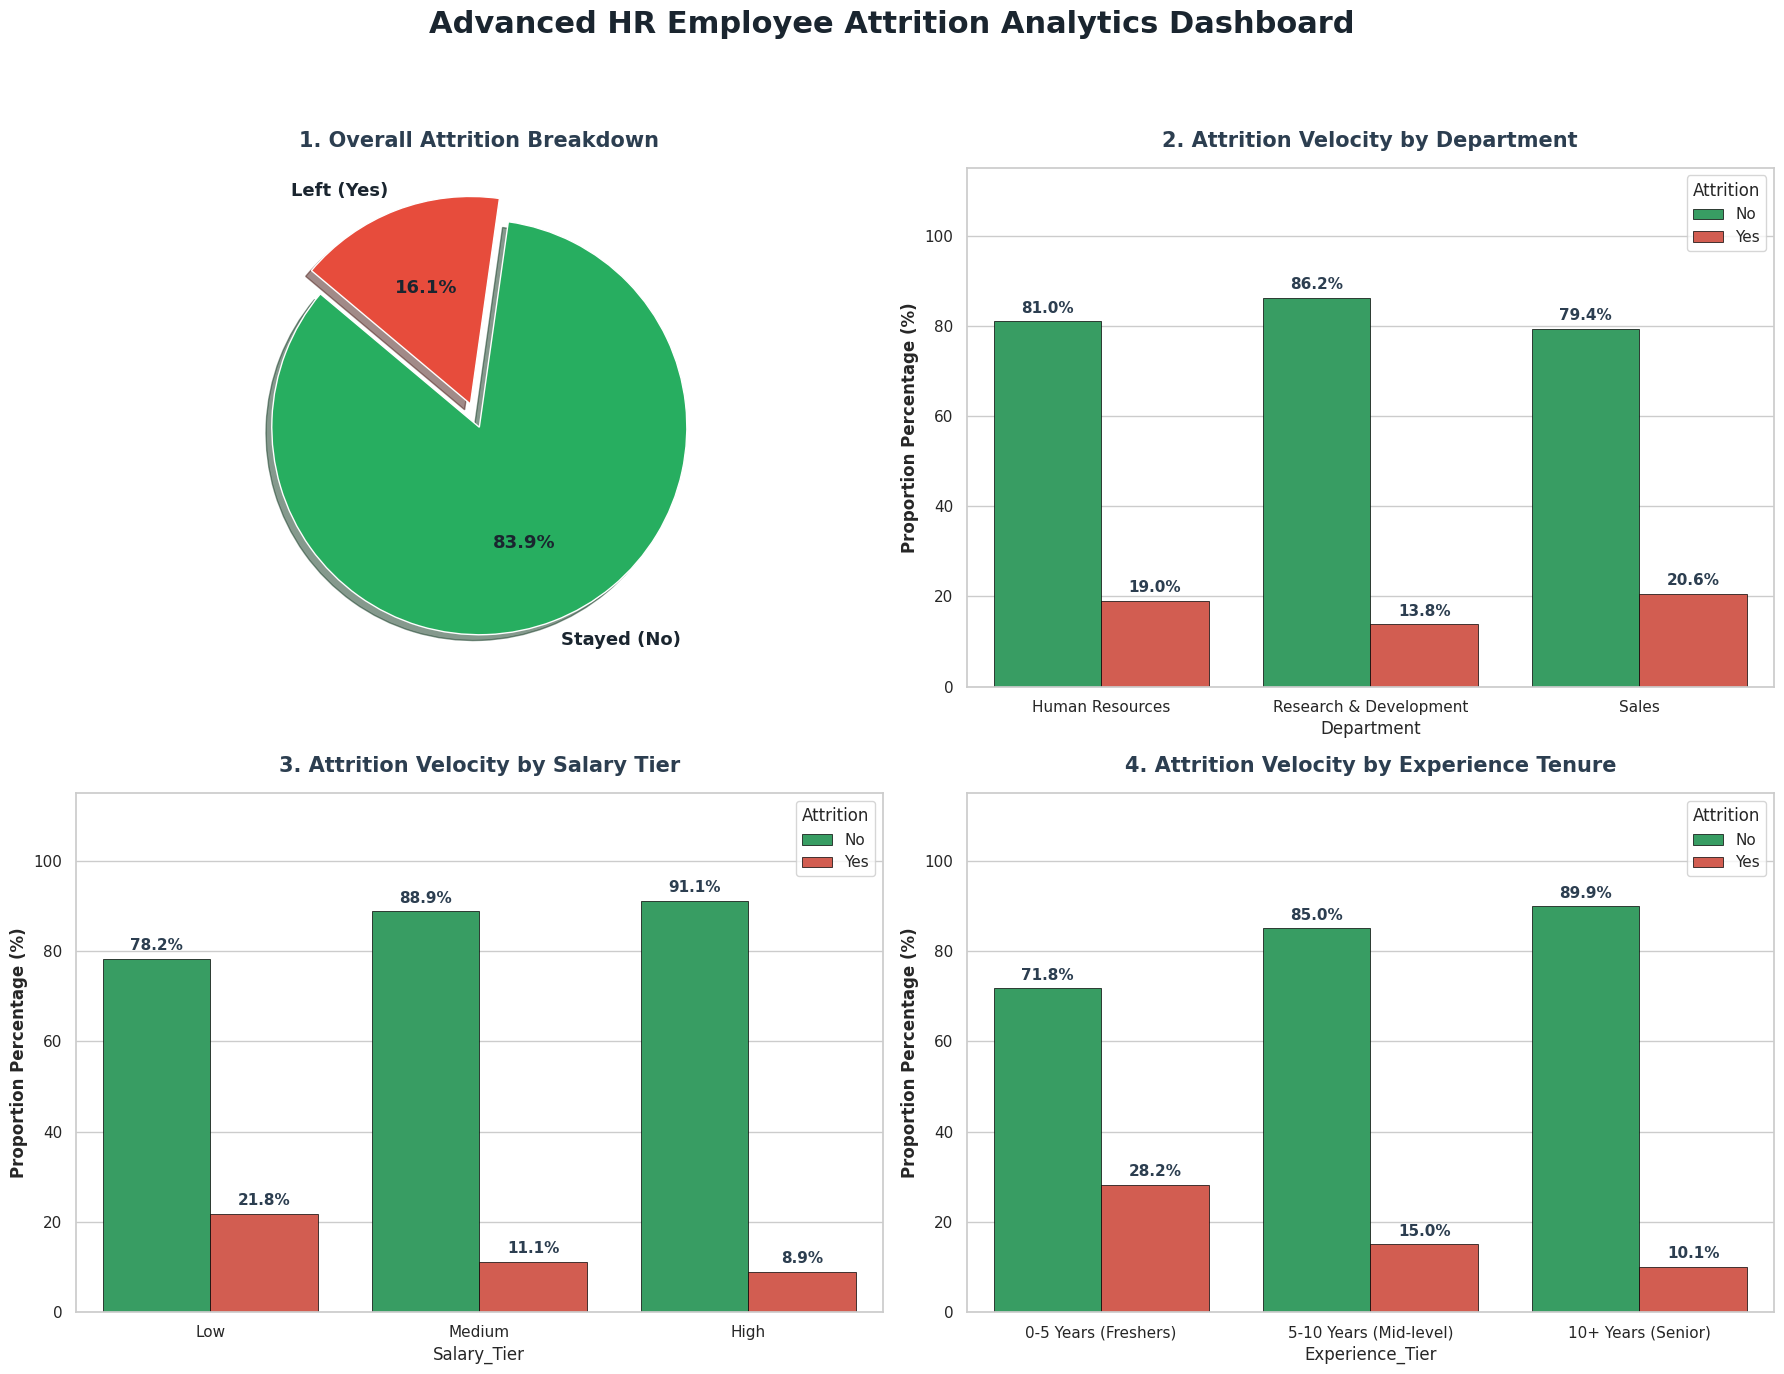

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if 'Salary_Tier' not in df_cleaned.columns:
    df_cleaned['Salary_Tier'] = pd.cut(df_cleaned['MonthlyIncome'], bins=[0, 5000, 10000, 25000], labels=['Low Salary', 'Medium Salary', 'High Salary'])
if 'Experience_Tier' not in df_cleaned.columns:
    df_cleaned['Experience_Tier'] = pd.cut(df_cleaned['TotalWorkingYears'], bins=[0, 5, 10, 40], labels=['0-5 Yrs (Fresher)', '5-10 Yrs (Mid-Level)', '10+ Yrs (Senior)'])

print("="*60)
print("             HR EMPLOYEE ATTRITION DATA REPORT            ")
print("="*60)

print("\n[1] OVERALL ATTRITION DISTRIBUTION:")
counts = df_cleaned['Attrition'].value_counts()
pct = df_cleaned['Attrition'].value_counts(normalize=True) * 100
for idx in counts.index:
    print(f"  Status: {idx:<5} | Count: {counts[idx]:<5} | Percentage: {pct[idx]:.1f}%")

print("\n[2] ATTRITION VELOCITY BY DEPARTMENT:")
dept_tab = pd.crosstab(df_cleaned['Department'], df_cleaned['Attrition'], normalize='index') * 100
print(dept_tab.round(1))

print("\n[3] ATTRITION VELOCITY BY SALARY TIER:")
salary_tab = pd.crosstab(df_cleaned['Salary_Tier'], df_cleaned['Attrition'], normalize='index') * 100
print(salary_tab.round(1))

print("\n[4] ATTRITION VELOCITY BY EXPERIENCE TENURE:")
exp_tab = pd.crosstab(df_cleaned['Experience_Tier'], df_cleaned['Attrition'], normalize='index') * 100
print(exp_tab.round(1))
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(18, 14), dpi=100)
fig.suptitle('Advanced HR Employee Attrition Analytics Dashboard', fontsize=22, fontweight='bold', color='#1a252f', y=0.98)

colors = ['#27ae60', '#e74c3c']
sns.set_theme(style="whitegrid")

def attach_percentage_labels(ax):
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=4, fontweight='bold', fontsize=11, color='#2c3e50')

# 1. Pie Chart
axes[0, 0].pie(counts, labels=['Stayed (No)', 'Left (Yes)'], autopct='%1.1f%%',
               startangle=140, colors=colors, explode=(0, 0.12), shadow=True,
               textprops={'fontsize': 13, 'weight': 'bold', 'color': '#1a252f'})
axes[0, 0].set_title('1. Overall Attrition Breakdown', fontsize=15, fontweight='bold', pad=15, color='#2c3e50')

# 2. Department Plot
dept_df = df_cleaned.groupby('Department', observed=False)['Attrition'].value_counts(normalize=True).rename('Percentage').reset_index()
dept_df['Percentage'] *= 100
ax1 = sns.barplot(x='Department', y='Percentage', hue='Attrition', data=dept_df, ax=axes[0, 1], palette=colors, edgecolor='black', linewidth=0.5)
axes[0, 1].set_title('2. Attrition Velocity by Department', fontsize=15, fontweight='bold', pad=15, color='#2c3e50')
axes[0, 1].set_ylabel('Proportion Percentage (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim(0, 115)
attach_percentage_labels(ax1)

# 3. Salary Plot
salary_df = df_cleaned.groupby('Salary_Tier', observed=False)['Attrition'].value_counts(normalize=True).rename('Percentage').reset_index()
salary_df['Percentage'] *= 100
ax2 = sns.barplot(x='Salary_Tier', y='Percentage', hue='Attrition', data=salary_df, ax=axes[1, 0], palette=colors, edgecolor='black', linewidth=0.5)
axes[1, 0].set_title('3. Attrition Velocity by Salary Tier', fontsize=15, fontweight='bold', pad=15, color='#2c3e50')
axes[1, 0].set_ylabel('Proportion Percentage (%)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylim(0, 115)
attach_percentage_labels(ax2)

# 4. Experience Plot
exp_df = df_cleaned.groupby('Experience_Tier', observed=False)['Attrition'].value_counts(normalize=True).rename('Percentage').reset_index()
exp_df['Percentage'] *= 100
ax3 = sns.barplot(x='Experience_Tier', y='Percentage', hue='Attrition', data=exp_df, ax=axes[1, 1], palette=colors, edgecolor='black', linewidth=0.5)
axes[1, 1].set_title('4. Attrition Velocity by Experience Tenure', fontsize=15, fontweight='bold', pad=15, color='#2c3e50')
axes[1, 1].set_ylabel('Proportion Percentage (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylim(0, 115)
attach_percentage_labels(ax3)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()